# Optimal pointing calculation for NIRCam

In this notebook we will:

1. Download an existing JWST observation to use as a reference DQ map and PSF
2. Find optimal regions for the 10110 SURVEY Cycle 5 program based on the dither pattern
3. Visualize the optimal regions and pick one pointing
4. Calculate the required offset to enter in APT for that pointing
5. Check the short wavelength channel to make sure we are not in a gap or on too many bad pixels

This is a streamlined version of `understand_pointing.ipynb`, in which I did a lot explaning and exploring.

## Tunable parameters

I tried grouping all the tunable parameters here to make the notebook easier to configure and re-run

In [ ]:
from coldest import pointing

SUBARRAY = "SUB400P"

if SUBARRAY is None or SUBARRAY == "FULL":
    TARGET_2473 = "WISE-1206"  # GO 2473 target for reference
    FILENAME = None
elif SUBARRAY == "FULLP":
    TARGET_2473 = None
    FILENAME = "jw06605006001_02109_00001_nrcblong_cal.fits"
elif SUBARRAY == "SUB400P":
    FILENAME = "jw01205002001_02104_00002_nrcblong_cal.fits"
    SUBARRAY = "SUB400P"
else:
    raise ValueError("Unexpected SUBARRAY")

if SUBARRAY == "FULLP":
    MIN_EDGE_DISTANCE = 200  # Minimum distance to keep from the LW detector edges
elif SUBARRAY == "SUB400P":
    MIN_EDGE_DISTANCE = 50  # Minimum distance to keep from the LW detector edges
else:
    MIN_EDGE_DISTANCE = 500  # Minimum distance to keep from the LW detector edges

FORBIDDEN_SIZE = 14  # Central region without bad pixels
CROP_SIZE = 70  # Region size to optimize pointing for
KERNEL = "weighted"  # PSF-weighted or uniform kernel in the region search?
N_TOP = 5  # Number of best regions to return after the search

#DITHER_PATTERN = "INTRAMODULEBOX"
DITHER_PATTERN = "SUBARRAY_DITHER"
NDITHERS = 4  # Number of dithers in the APT

DITHER_FILES = {
    "INTRAMODULEBOX": "NircamImagingIntramoduleBox.txt",
    "SUBARRAY_DITHER": "NircamImagingSubarrayDither.txt",
}

hs = CROP_SIZE // 2

SAVE = True
OUT_DIR = None

## Downloading an existing observation

We first download an existing observation.
We will use this to derive the bad pixel map and to extract a reference PSF we will use as a kernel in our grid search.

In [2]:
from pathlib import Path
from astroquery.mast import Observations
import pandas as pd
from coldest import download

data_path = Path("./data")

if FILENAME is not None:
    filename = FILENAME
    file_id_nodet = "_".join(filename.split("_")[:-2])
    path_lw, x, y = download.download_other(filename, data_path)
elif TARGET_2473 is not None:
    pos_df = pd.read_csv("../resources/position_file_2473.csv", comment="#")
    filename = download.get_2473_filename(pos_df, TARGET_2473)
    file_id_nodet = "_".join(filename.split("_")[:-2])
    path_lw, x, y = download.download_2473(filename, data_path, pos_df)
else:
    raise TypeError("TARGET_2473 or FILENAME are required for this notebook to run")

INFO: Found cached file data/jw06605006001_02109_00001_nrcblong_cal.fits with expected size 117573120. [astroquery.query]


In [3]:
if SAVE:
    if OUT_DIR is None:
        out_dir = f"results/pointing_ref_{filename}_subarray_{SUBARRAY}_kernel_{KERNEL}"
    else:
        out_dir = OUT_DIR
    out_dir_base = out_dir
    i = 1
    out_dir = Path(out_dir)
    while out_dir.is_dir():
        out_dir = Path(f"{out_dir_base}_{i}")
        i += 1
    out_dir.mkdir(parents=True)


def figsave(fname: str, fig=None):
    if SAVE:
        if fig is not None:
            fig.savefig(out_dir / fname)
        else:
            plt.savefig(out_dir / fname)

Let us extract the header and science data, and derive the DQ map.
We can then take a quick look at the data.

In [4]:
from astropy.io import fits
import numpy as np

with fits.open(path_lw) as hdul:
    hdr = hdul[0].header
    img = hdul["SCI"].data
target = hdr["TARGPROP"]
dq_mask = np.isnan(img)

In [5]:
created_date = hdr["DATE"]
crds_ver = hdr["CRDS_VER"]
crds_ctx = hdr["CRDS_CTX"]
cal_ver = hdr["CAL_VER"]
print(f"The file was processed on {created_date} with pipline version {cal_ver}, CRDS version {crds_ver}, context {crds_ctx}")
if SAVE:
    with open(out_dir / "versions.txt", "w") as f:
        f.write(f"The file was processed on {created_date} with pipline version {cal_ver}, CRDS version {crds_ver}, context {crds_ctx}")

The file was processed on 2025-12-30T16:00:59.499 with pipline version 1.20.2, CRDS version 13.0.6, context jwst_1464.pmap


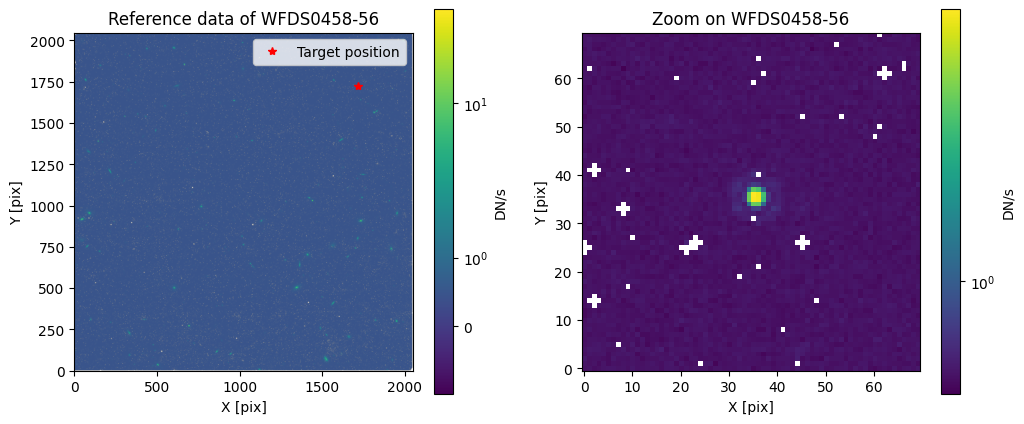

In [6]:
from matplotlib import rcParams
import matplotlib.pyplot as plt

img_crop = img[y - hs: y + hs, x - hs: x + hs]

rcParams["image.origin"] = "lower"

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axf, axz = axs

im = axf.imshow(img, norm="symlog")
axf.plot(x, y, "r*", label="Target position")
axf.set_title(f"Reference data of {target}")
axf.set_xlabel("X [pix]")
axf.set_ylabel("Y [pix]")
fig.colorbar(im, label="DN/s")
axf.legend()

im = axz.imshow(img_crop, norm="symlog")
axz.set_title(f"Zoom on {target}")
axz.set_xlabel("X [pix]")
axz.set_ylabel("Y [pix]")
fig.colorbar(im, label="DN/s")

figsave("ref_img.pdf")
plt.show()

Finally, we will filter the cropped image to remove the bad pixels
and have a reference PSF for display and region search purposes.

In [7]:
psf = pointing.filter_crop(img_crop)

## Searching the optimal region

Now is time to run our region search code.
We run it for all the dithers at once so we first need to load the dither offsets.

### Getting dither positions

We use the dither offsets from the [dither file](https://jwst-docs.stsci.edu/files/216457358/216457359/2/1763675557795/NIRCamDitherPatterns.zip)
downloadable from [JDox](https://jwst-docs.stsci.edu/jwst-near-infrared-camera/nircam-operations/nircam-dithers-and-mosaics/nircam-primary-dithers#gsc.tab=0).

We already copied the `INTRAMODULEBOX` file to `resources`.

In [8]:
dither_file = DITHER_FILES[DITHER_PATTERN]
dither_df = pd.read_csv(
    f"../resources/{dither_file}",
    sep=r"\s+",
    skiprows=1,
    header=None,
    names=["x_docs", "y_docs"],
    index_col=0,
).reset_index(drop=True)[:NDITHERS]

And then we convert the dithers from arcsec to pixel coordinates

In [9]:
pscale = pointing.PSCALE_DICT[hdr["DETECTOR"]]

# Convert to pixels
x_dithers = (dither_df.x_docs / pscale).values
y_dithers = (dither_df.y_docs / pscale).values

# Format for do_region_search()
dither_offsets = [xy for xy in zip(x_dithers, y_dithers)]

### Running the search

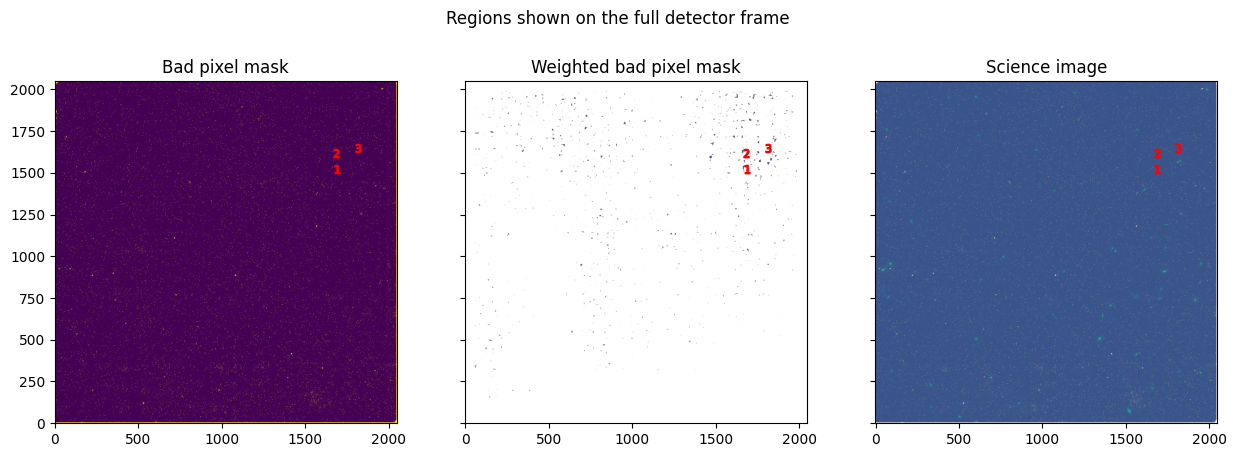

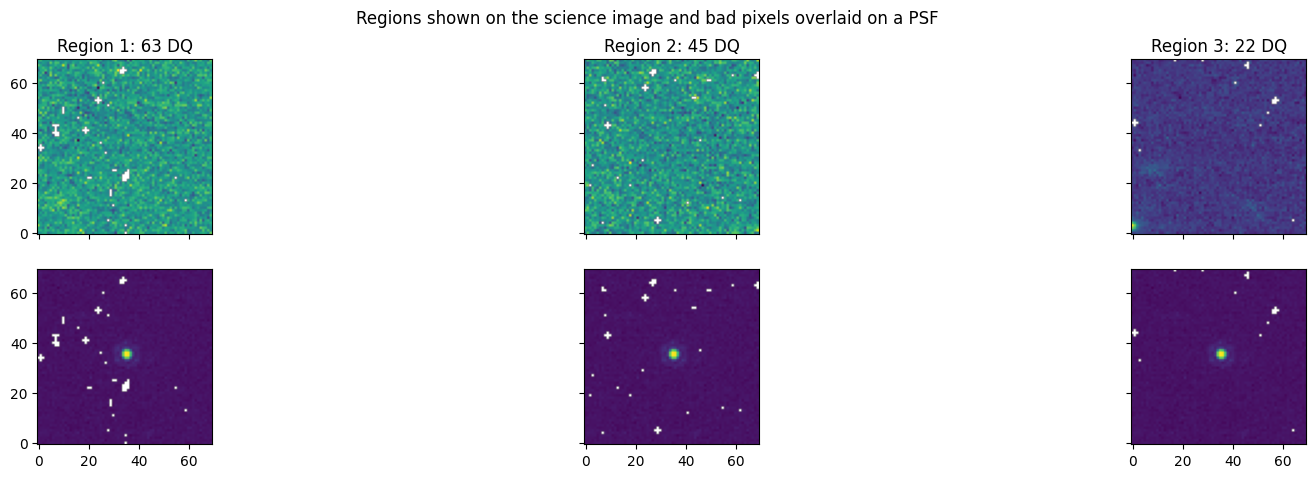

In [10]:
best_x_dith, best_y_dith = pointing.do_region_search(
    dq_mask,
    img,
    CROP_SIZE,
    psf,
    n_top=N_TOP,
    show=True,
    joint_offsets=dither_offsets,
    forbidden_size=FORBIDDEN_SIZE,
    kernel=KERNEL,
    min_edge_distance=MIN_EDGE_DISTANCE,
    subarray=SUBARRAY,
)

### Visualizing best pointing

Now that we have the `N_TOP` best pointings, enabling us to manually select one.

For each pointing, we show:

- The dithers on the full frame
- A zoom on each dither in the reference image
- A zoom on the DQ map overlaid on a PSF

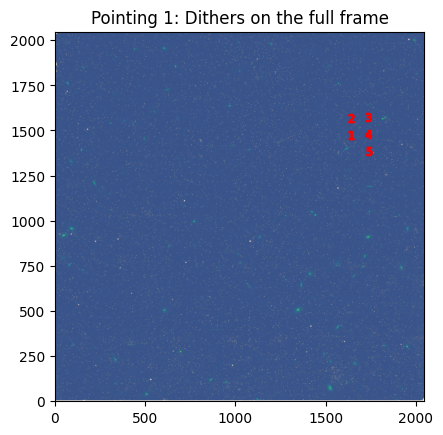

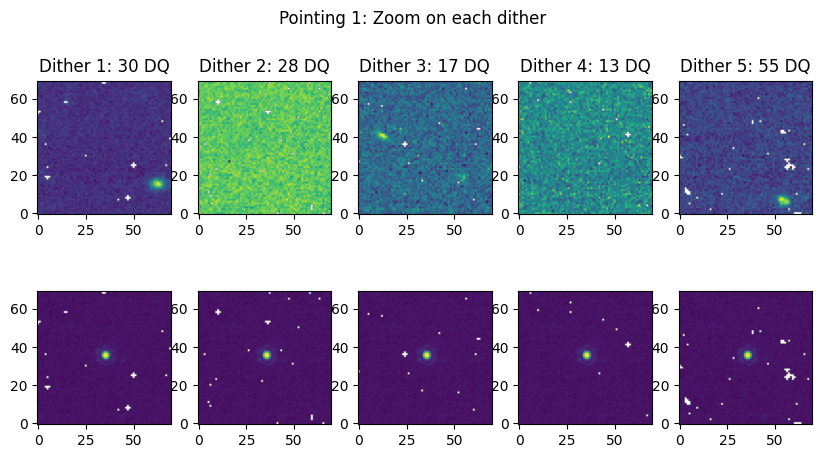

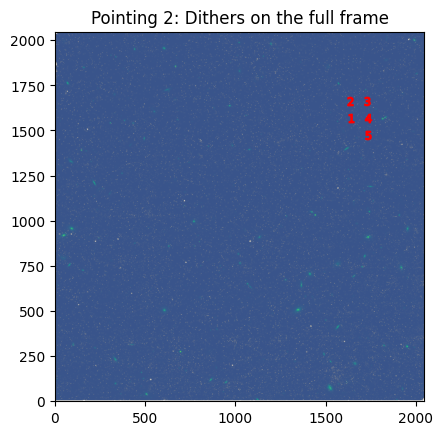

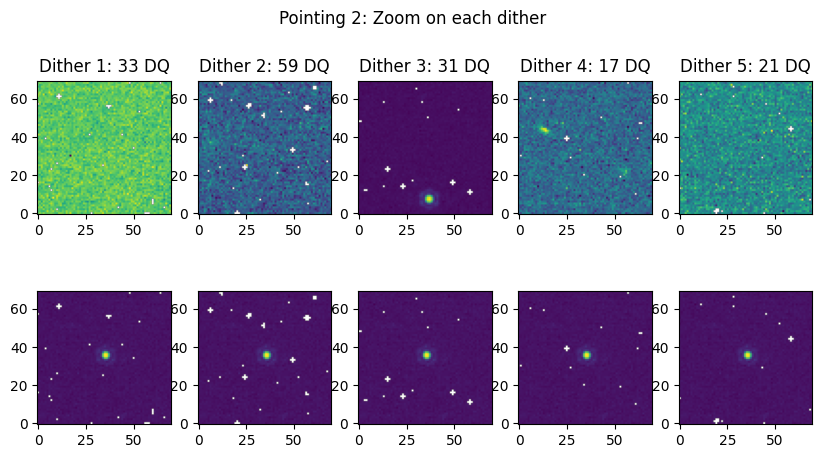

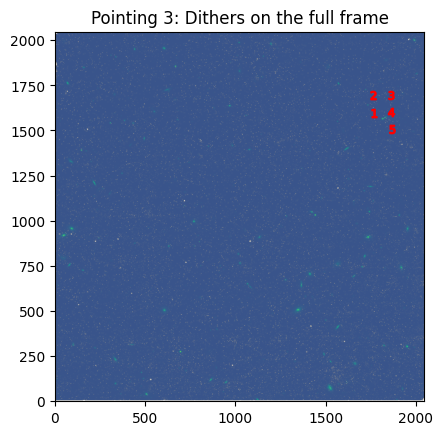

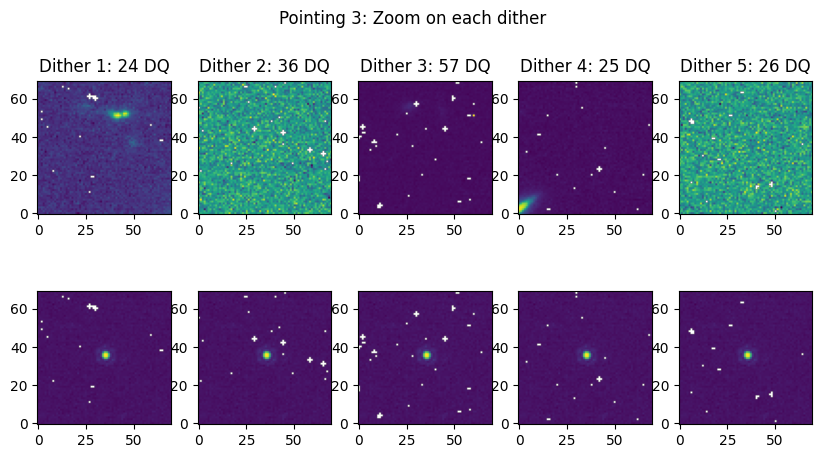

In [11]:
for i in range(N_TOP):
    xopt, yopt = best_x_dith[i], best_y_dith[i]
    xopt_all, yopt_all = xopt + x_dithers.astype(int), yopt + y_dithers.astype(int)
    fig_full, fig_zoom = pointing.plot_dithers(img, xopt_all, yopt_all, CROP_SIZE, psf)
    fig_full.axes[0].set_title(f"Pointing {i+1}: Dithers on the full frame")
    fig_zoom.suptitle(f"Pointing {i+1}: Zoom on each dither")
    figsave(f"dithers_full_{i+1}.pdf", fig=fig_full)
    figsave(f"dithers_zoom_{i+1}.pdf", fig=fig_zoom)
    plt.show()

We will also generate these plots on the reference position, to make sure the offset is not making things worse.

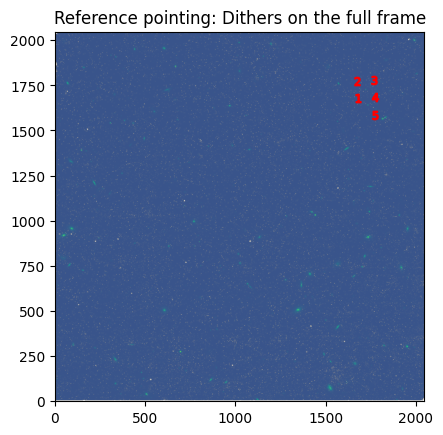

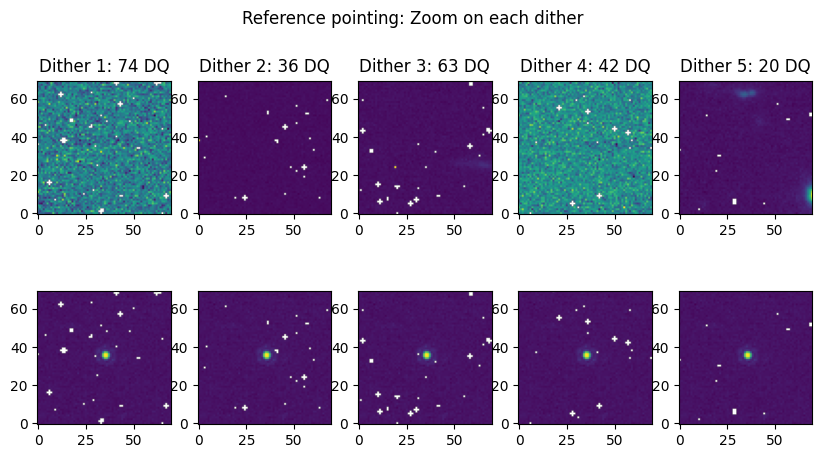

In [12]:
x0, y0 = pointing.apply_pointing(0, 0, path_lw)
x0_all, y0_all = x0 + x_dithers.astype(int), y0 + y_dithers.astype(int)
fig_full, fig_zoom = pointing.plot_dithers(img, x0_all, y0_all, CROP_SIZE, psf)
fig_full.axes[0].set_title(f"Reference pointing: Dithers on the full frame")
fig_zoom.suptitle(f"Reference pointing: Zoom on each dither")
figsave(f"dithers_full_ref.pdf", fig=fig_full)
figsave(f"dithers_zoom_ref.pdf", fig=fig_zoom)
plt.show()
plt.ioff()

## Selecting a pointing and calculating the offset

Based on the plots above, we can pick our favorite pointing position by setting `opt_idx` below (starting from 0).
Setting `opt_idx` will not apply any offset and instead use the reference position for the subarray.
This will tell us the position to enter in the APT.

In [21]:
opt_idx = 3

if opt_idx == -1:
    xopt, yopt = x0, y0
else:
    xopt, yopt = best_x_dith[opt_idx], best_y_dith[opt_idx]
xopt_all, yopt_all = xopt + x_dithers.astype(int), yopt + y_dithers.astype(int)

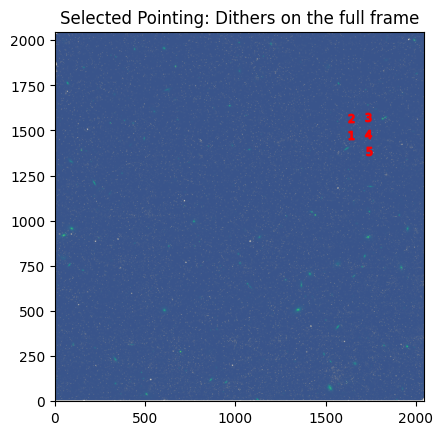

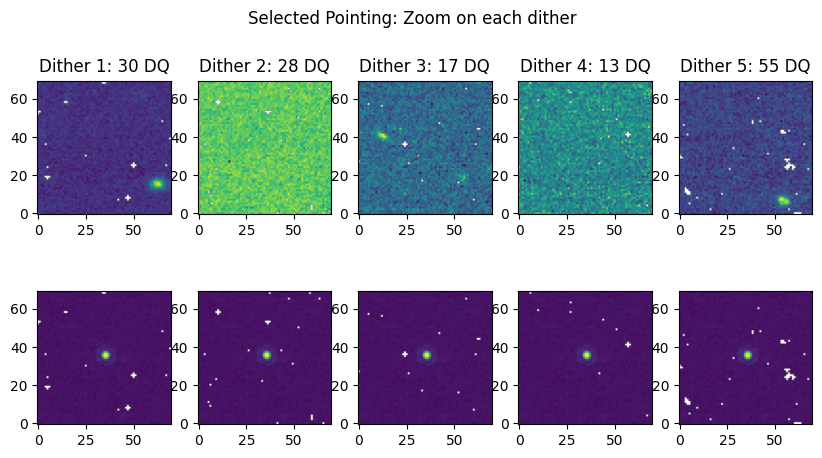

In [22]:
fig_full, fig_zoom = pointing.plot_dithers(img, xopt_all, yopt_all, CROP_SIZE, psf)
fig_full.axes[0].set_title(f"Selected Pointing: Dithers on the full frame")
fig_zoom.suptitle(f"Selected Pointing: Zoom on each dither")
plt.show()

In [23]:
from coldest.pointing import calculate_offset

xoff, yoff = calculate_offset(xopt, yopt, path_lw)

print(f"Desired offset in arcsec: {xoff:.3f}, {yoff:.3f}")
if SAVE:
    np.savetxt(out_dir / "xoff_yoff.txt", np.array([[xoff, yoff]]))
    with open(out_dir / "xoff_yoff_human.txt", "w") as f:
        f.write(f"Desired offset in arcsec: {xoff:.3f}, {yoff:.3f}")

Desired offset in arcsec: -2.321, -12.855


## Checking the short wavelength channel

We are also observing the the short-wavelength (SW) channel.
Let us check that the pointing does not fall in the detector gap and that it does not fall on a region with too many bad pixels.

First we load reference observations for all available SW detectors since the pointing might fall on any of them (in subarray FULL).

In [24]:
file_ids_sw = [f"{file_id_nodet}_nrcb{i}" for i in range(1, 5)]
path_sw_list = []
for file_id in file_ids_sw:
    uri_sw = f"mast:JWST/product/{file_id}_cal.fits"
    path_sw = data_path / uri_sw.split("/")[-1]
    path_sw_list.append(path_sw)
    Observations.download_file(uri_sw, local_path=path_sw);

INFO: Found cached file data/jw06605006001_02109_00001_nrcb1_cal.fits with expected size 117573120. [astroquery.query]


Then we load the detector corresponding to the reference pointing to get a SW reference PSF.

In [25]:
det_sw_ref = pointing.get_sw_detector(x, y, SUBARRAY)
path_sw = data_path / f"{file_id_nodet}_{det_sw_ref}_cal.fits"
img_sw = fits.open(path_sw)["SCI"].data
x_sw, y_sw = tuple(int(xi) for xi in pointing.long_to_short(x, y, path_lw, path_sw))

img_crop_sw = img_sw[y_sw - hs: y_sw + hs, x_sw - hs: x_sw + hs]
psf_sw = pointing.filter_crop(img_crop_sw)

And finally we determine which SW detector our pointing will fall on and display the resulting detector positions.

In [26]:
det_sw = pointing.get_sw_detector(xopt, yopt, SUBARRAY)
path_sw = data_path / f"{file_id_nodet}_{det_sw}_cal.fits"

In [27]:
xopt_all_sw, yopt_all_sw = zip(*[pointing.long_to_short(xi, yi, path_lw, path_sw) for xi, yi in zip(xopt_all, yopt_all)])

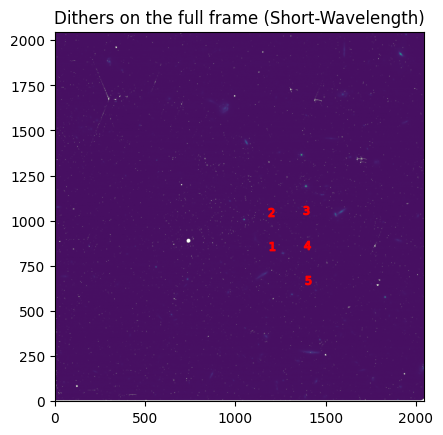

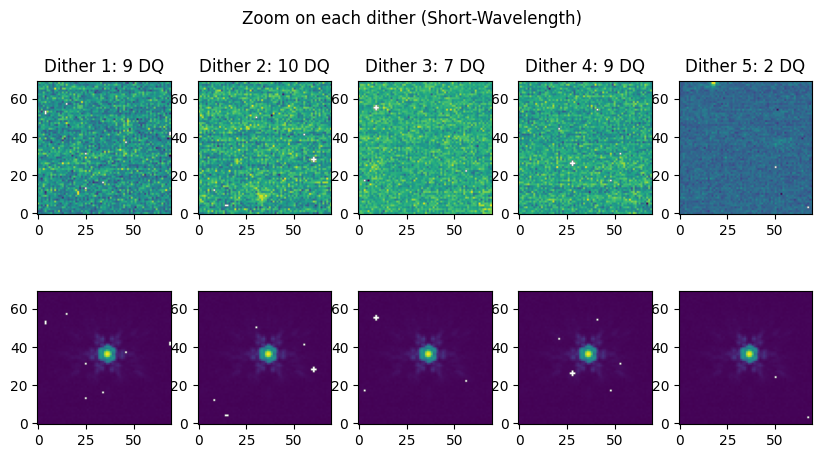

In [28]:
fig_full, fig_zoom = pointing.plot_dithers(img_sw, xopt_all_sw, yopt_all_sw, CROP_SIZE, psf=psf_sw)
fig_full.axes[0].set_title("Dithers on the full frame (Short-Wavelength)")
fig_zoom.suptitle("Zoom on each dither (Short-Wavelength)")
figsave(f"dithers_full_sw.pdf", fig=fig_full)
figsave(f"dithers_zoom_sw.pdf", fig=fig_zoom)
plt.show()